# Slow SW Fit

Minimal notebook for loading ACE-at-Earth solar-wind data.

In [36]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents, Path("/home/smdc/helio-n")):
    if (candidate / "Library").exists() and (candidate / "Config").exists():
        project_root = candidate
        break
assert (
    project_root is not None
), "Could not locate the helio-n project root for notebook imports."
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from Library.SW.Inputs import load_ace_at_earth
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [61]:
df_ace_earth = load_ace_at_earth()
df_ace_earth

,v_ace
date,
2010-08-01 00:00:00,526.025000
2010-08-01 01:00:00,521.029167
2010-08-01 02:00:00,524.886667
2010-08-01 03:00:00,528.753333
2010-08-01 04:00:00,521.786667
...,...
2023-12-31 16:00:00,299.126744
2023-12-31 21:00:00,317.418421
2023-12-31 22:00:00,319.443103


In [ ]:
df_ace_earth_slow = df_ace_earth.loc[df_ace_earth.v_ace <= 350].dropna()


In [48]:
ydata = df_ace_earth_slow['v_ace'].to_numpy()
ydata

array([339.66083333, 336.26166667, 334.67166667, ..., 317.41842105,
       319.44310345, 319.16666667])

In [49]:
xdata = ((df_ace_earth_slow.index - df_ace_earth_slow.index[0]) / pd.Timedelta("1h")).to_numpy()
xdata

array([0.00000e+00, 1.00000e+00, 2.00000e+00, ..., 1.17345e+05,
       1.17346e+05, 1.17347e+05])

In [55]:
def func(xdata, k, b):
    return k * xdata + b

In [51]:
def func(xdata, a, b, c):
    return a * xdata ** 2 + b * xdata + c

In [56]:
xfine = np.linspace(xdata.min(), xdata.max(), 100)

In [57]:
popt, pcov = curve_fit(func, xdata, ydata)


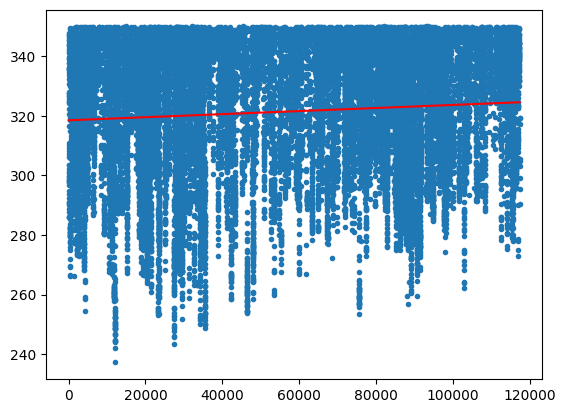

In [58]:
plt.plot(xdata, ydata, '.');
plt.plot(xfine, func(xfine, *popt),'r-')

In [59]:
popt

array([5.15349738e-05, 3.18513089e+02])